In [96]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/2023-kaggle-ai-report/sample_submission.csv
/kaggle/input/2023-kaggle-ai-report/arxiv_metadata_20230510.json
/kaggle/input/2023-kaggle-ai-report/kaggle_writeups_20230510.csv


In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns= None

In [98]:
df = pd.read_csv('/kaggle/input/2023-kaggle-ai-report/kaggle_writeups_20230510.csv')
df.head()

,Competition Launch Date,Title of Competition,Competition URL,Date of Writeup,Title of Writeup,Writeup,Writeup URL
0,08/03/2010 00:00:00,Chess ratings - Elo versus the Rest of the World,https://www.kaggle.com/c/2447,11/18/2010 00:06:46,Released: my Source Code and Analysis,<p>I had a lot of fun with this competition an...,https://www.kaggle.com/c/2447/discussion/185
1,08/03/2010 00:00:00,Chess ratings - Elo versus the Rest of the World,https://www.kaggle.com/c/2447,11/20/2010 04:38:53,6th place(UriB) by Uri Blass,<P>I calculated rating for every player in mon...,https://www.kaggle.com/c/2447/discussion/192
2,08/03/2010 00:00:00,Chess ratings - Elo versus the Rest of the World,https://www.kaggle.com/c/2447,11/23/2010 10:38:23,7th place - littlefish,I'm a little surprised I ended up in the top-1...,https://www.kaggle.com/c/2447/discussion/194
3,08/03/2010 00:00:00,Chess ratings - Elo versus the Rest of the World,https://www.kaggle.com/c/2447,11/20/2010 11:27:17,3rd place: Chessmetrics - Variant,"<p><span id=""post_text_content_1230""><div dir=...",https://www.kaggle.com/c/2447/discussion/193
4,08/03/2010 00:00:00,Chess ratings - Elo versus the Rest of the World,https://www.kaggle.com/c/2447,11/18/2010 02:44:10,2nd place: TrueSkill Through Time,"Wow, this is a surprise! I looked at this comp...",https://www.kaggle.com/c/2447/discussion/186


In [99]:
df.infer_objects()

,Competition Launch Date,Title of Competition,Competition URL,Date of Writeup,Title of Writeup,Writeup,Writeup URL
0,08/03/2010 00:00:00,Chess ratings - Elo versus the Rest of the World,https://www.kaggle.com/c/2447,11/18/2010 00:06:46,Released: my Source Code and Analysis,<p>I had a lot of fun with this competition an...,https://www.kaggle.com/c/2447/discussion/185
1,08/03/2010 00:00:00,Chess ratings - Elo versus the Rest of the World,https://www.kaggle.com/c/2447,11/20/2010 04:38:53,6th place(UriB) by Uri Blass,<P>I calculated rating for every player in mon...,https://www.kaggle.com/c/2447/discussion/192
2,08/03/2010 00:00:00,Chess ratings - Elo versus the Rest of the World,https://www.kaggle.com/c/2447,11/23/2010 10:38:23,7th place - littlefish,I'm a little surprised I ended up in the top-1...,https://www.kaggle.com/c/2447/discussion/194
3,08/03/2010 00:00:00,Chess ratings - Elo versus the Rest of the World,https://www.kaggle.com/c/2447,11/20/2010 11:27:17,3rd place: Chessmetrics - Variant,"<p><span id=""post_text_content_1230""><div dir=...",https://www.kaggle.com/c/2447/discussion/193
4,08/03/2010 00:00:00,Chess ratings - Elo versus the Rest of the World,https://www.kaggle.com/c/2447,11/18/2010 02:44:10,2nd place: TrueSkill Through Time,"Wow, this is a surprise! I looked at this comp...",https://www.kaggle.com/c/2447/discussion/186
...,...,...,...,...,...,...,...
3122,02/23/2023 17:25:32,Google - Isolated Sign Language Recognition,https://www.kaggle.com/c/46105,05/02/2023 09:45:01,49th place silver solution,<p>Thank you Kaggle and Pop sign for hosting t...,https://www.kaggle.com/c/46105/discussion/406426
3123,02/23/2023 17:25:32,Google - Isolated Sign Language Recognition,https://www.kaggle.com/c/46105,05/02/2023 10:13:31,10th place solution,"<blockquote>\n <p>First, I would like to than...",https://www.kaggle.com/c/46105/discussion/406434
3124,02/23/2023 17:25:32,Google - Isolated Sign Language Recognition,https://www.kaggle.com/c/46105,05/02/2023 03:24:28,Solution - Single transformer without val dataset,<p>Thanks to the organisers of the PopSign Gam...,https://www.kaggle.com/c/46105/discussion/406346
3125,02/23/2023 17:25:32,Google - Isolated Sign Language Recognition,https://www.kaggle.com/c/46105,05/02/2023 04:01:15,Top 8% Bronze Medal Solution,<blockquote>\n <p><strong>Many congratulation...,https://www.kaggle.com/c/46105/discussion/406354


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3127 entries, 0 to 3126
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Competition Launch Date  3127 non-null   object
 1   Title of Competition     3127 non-null   object
 2   Competition URL          3127 non-null   object
 3   Date of Writeup          3127 non-null   object
 4   Title of Writeup         3127 non-null   object
 5   Writeup                  3125 non-null   object
 6   Writeup URL              3127 non-null   object
dtypes: object(7)
memory usage: 171.1+ KB


In [101]:
df.dtypes

Competition Launch Date    object
Title of Competition       object
Competition URL            object
Date of Writeup            object
Title of Writeup           object
Writeup                    object
Writeup URL                object
dtype: object

In [102]:
df.describe().T

,count,unique,top,freq
Competition Launch Date,3127,309,08/30/2022 17:23:07,45
Title of Competition,3127,310,Feedback Prize - English Language Learning,45
Competition URL,3127,310,https://www.kaggle.com/c/38321,45
Date of Writeup,3127,3117,04/25/2020 13:17:57,2
Title of Writeup,3127,2469,1st place solution,44
Writeup,3125,3115,<p>Thanks to my teammates @dott1718 and @chris...,2
Writeup URL,3127,3127,https://www.kaggle.com/c/2447/discussion/185,1


In [103]:
df.isnull().sum()/len(df)*100

Competition Launch Date    0.000000
Title of Competition       0.000000
Competition URL            0.000000
Date of Writeup            0.000000
Title of Writeup           0.000000
Writeup                    0.063959
Writeup URL                0.000000
dtype: float64

In [104]:
df.shape

(3127, 7)

In [105]:
df.skew()

/tmp/ipykernel_35/1665899112.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.skew()


Series([], dtype: float64)

In [106]:
df.kurt()

/tmp/ipykernel_35/1257127604.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.kurt()


Series([], dtype: float64)

In [107]:
Q1 = df.quantile(0.25)
Q2 = df.quantile(0.5)
Q3 = df.quantile(0.75)
IQR=Q3-Q1
print(IQR)

Series([], dtype: float64)


/tmp/ipykernel_35/151362466.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = df.quantile(0.25)
/tmp/ipykernel_35/151362466.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = df.quantile(0.5)
/tmp/ipykernel_35/151362466.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = df.quantile(0.75)


In [108]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [109]:
df_new = df[~(df>UL)|(df<LL).any(axis=1)]

/tmp/ipykernel_35/391172524.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  df_new = df[~(df>UL)|(df<LL).any(axis=1)]


In [110]:
df_new.shape

(3127, 7)

<AxesSubplot: >

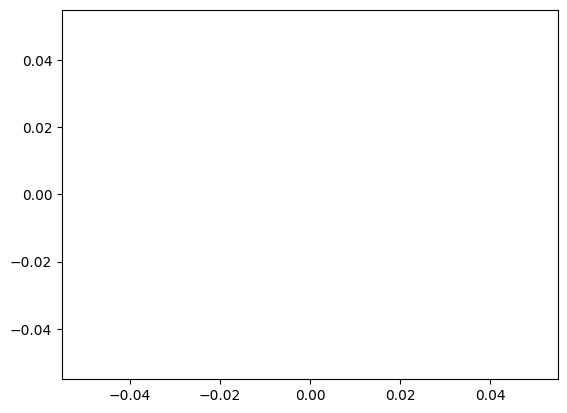

In [111]:
sns.scatterplot(df)

In [112]:
df['Title of Competition']=df['Title of Competition'].map({'Good':2,'Standard':1,'Poor':0})

/tmp/ipykernel_35/3130417409.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True,cmap='afmhot_r')
/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/conda/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


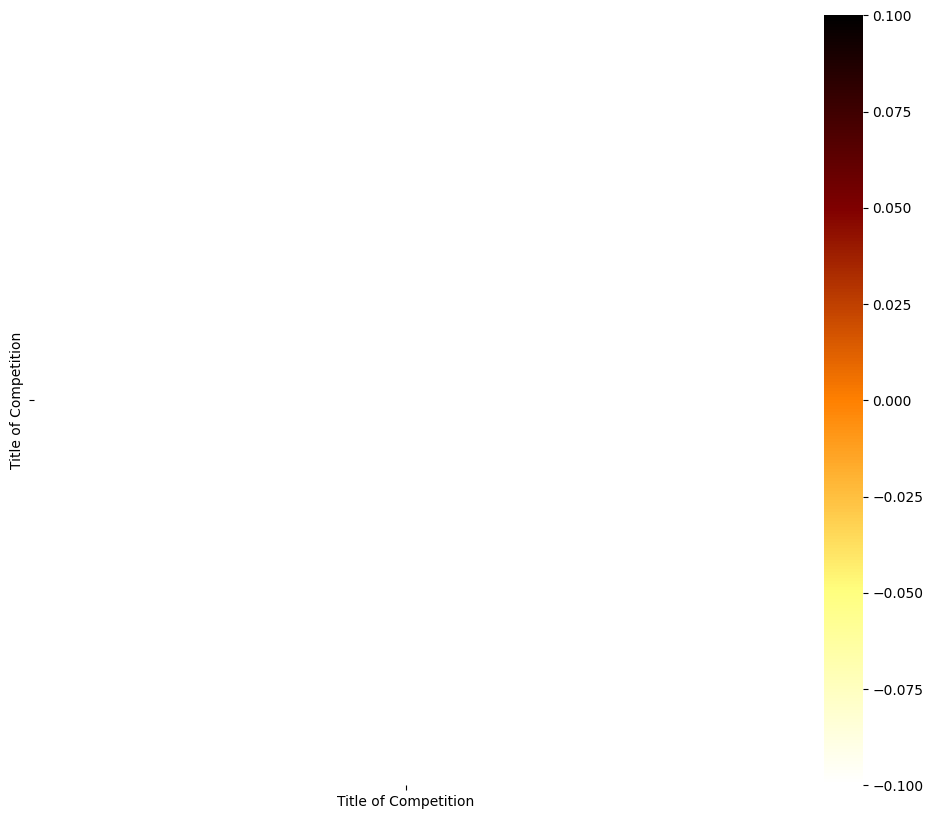

In [113]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap='afmhot_r')
plt.show()

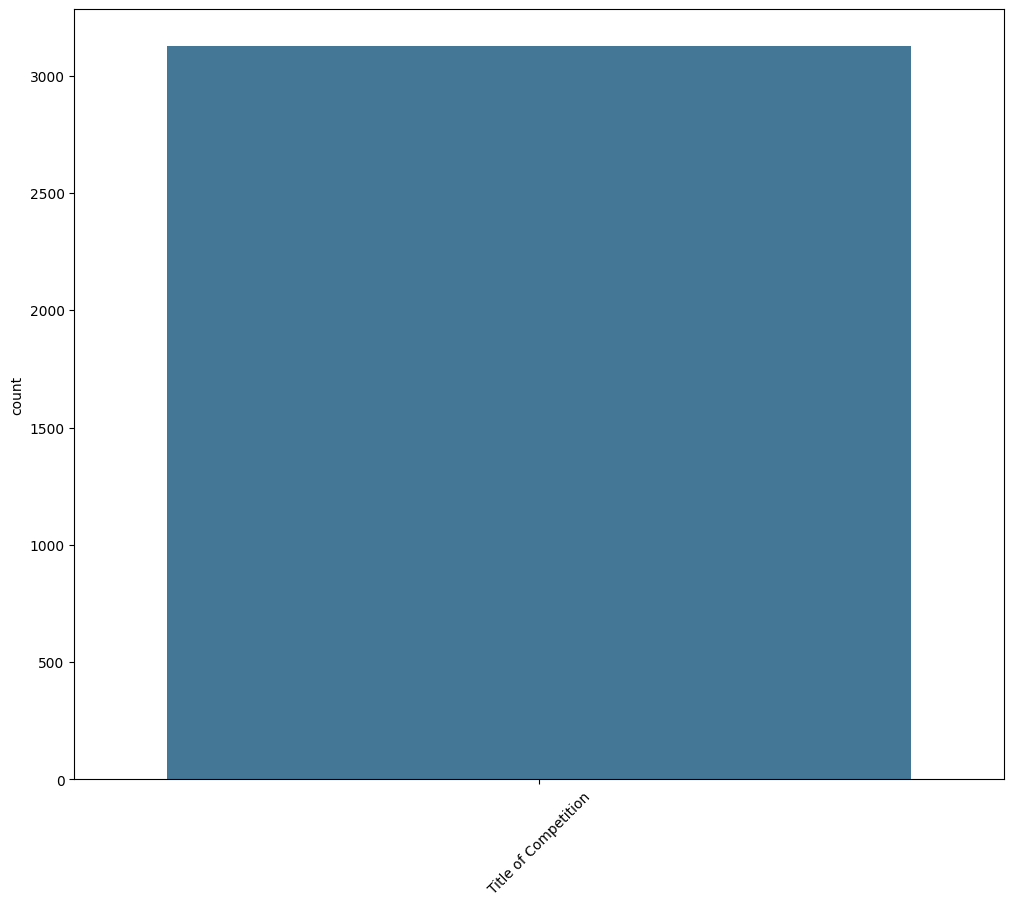

In [114]:
plt.figure(figsize=(12,10))
sns.countplot(df,palette='mako');
plt.xticks(rotation=45);

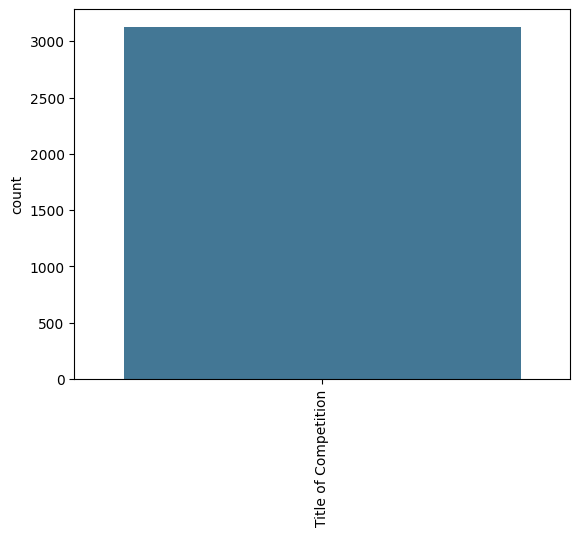

In [115]:
sns.countplot(df,palette='mako');
plt.xticks(rotation=90);

(array([0]), [Text(0, 0, 'Title of Competition')])

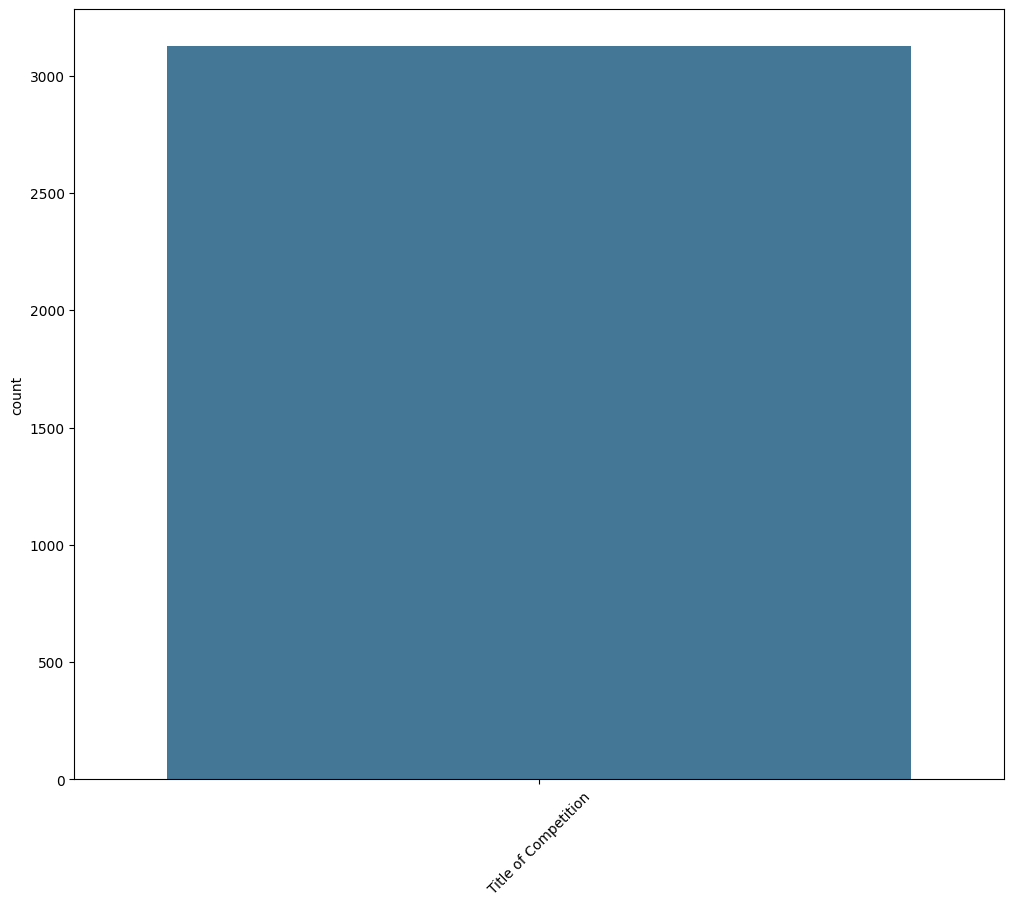

In [116]:
plt.figure(figsize=(12,10))
sns.countplot(df,palette='mako')
plt.xticks(rotation=45)

In [117]:
cat_cols = df.select_dtypes(include='object')

In [118]:
for i in cat_cols:
    print(i)
    print(df[i].value_counts())
    print('_'*50)

Competition Launch Date
08/30/2022 17:23:07    45
11/19/2020 21:12:46    41
10/05/2020 17:24:56    37
03/03/2020 00:19:01    36
11/22/2019 17:56:22    35
                       ..
11/14/2016 08:02:32     1
01/25/2013 18:13:24     1
01/11/2013 00:57:00     1
01/09/2015 18:35:41     1
06/22/2017 16:00:23     1
Name: Competition Launch Date, Length: 309, dtype: int64
__________________________________________________
Competition URL
https://www.kaggle.com/c/38321    45
https://www.kaggle.com/c/13836    41
https://www.kaggle.com/c/21651    37
https://www.kaggle.com/c/18599    36
https://www.kaggle.com/c/7968     35
                                  ..
https://www.kaggle.com/c/3517      1
https://www.kaggle.com/c/3354      1
https://www.kaggle.com/c/3370      1
https://www.kaggle.com/c/3984      1
https://www.kaggle.com/c/3445      1
Name: Competition URL, Length: 310, dtype: int64
__________________________________________________
Date of Writeup
04/25/2020 13:17:57    2
05/30/2020 14:53:1

In [119]:
num_cols = df.select_dtypes('number')

In [120]:
for i in num_cols:
    print(i)
    print(df[i].value_counts())
    print('_'*50)

Title of Competition
Series([], Name: Title of Competition, dtype: int64)
__________________________________________________


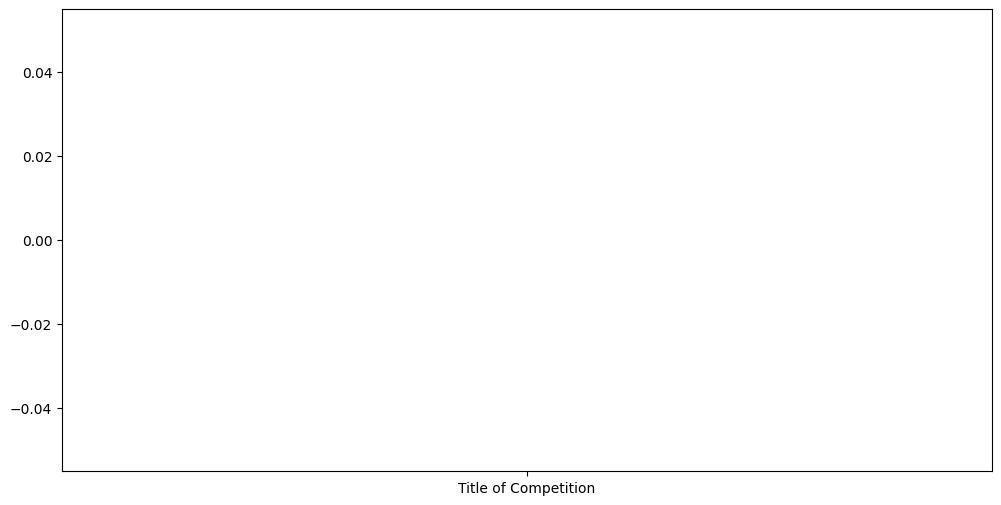

In [121]:
df.plot(kind='box', subplots=True,sharey = False, figsize=(12,6))
plt.subplots_adjust(wspace=0.75)
plt.show()

In [122]:
df['Title of Competition'].unique()

array([nan])

In [123]:
df['Title of Competition'].value_counts()

Series([], Name: Title of Competition, dtype: int64)

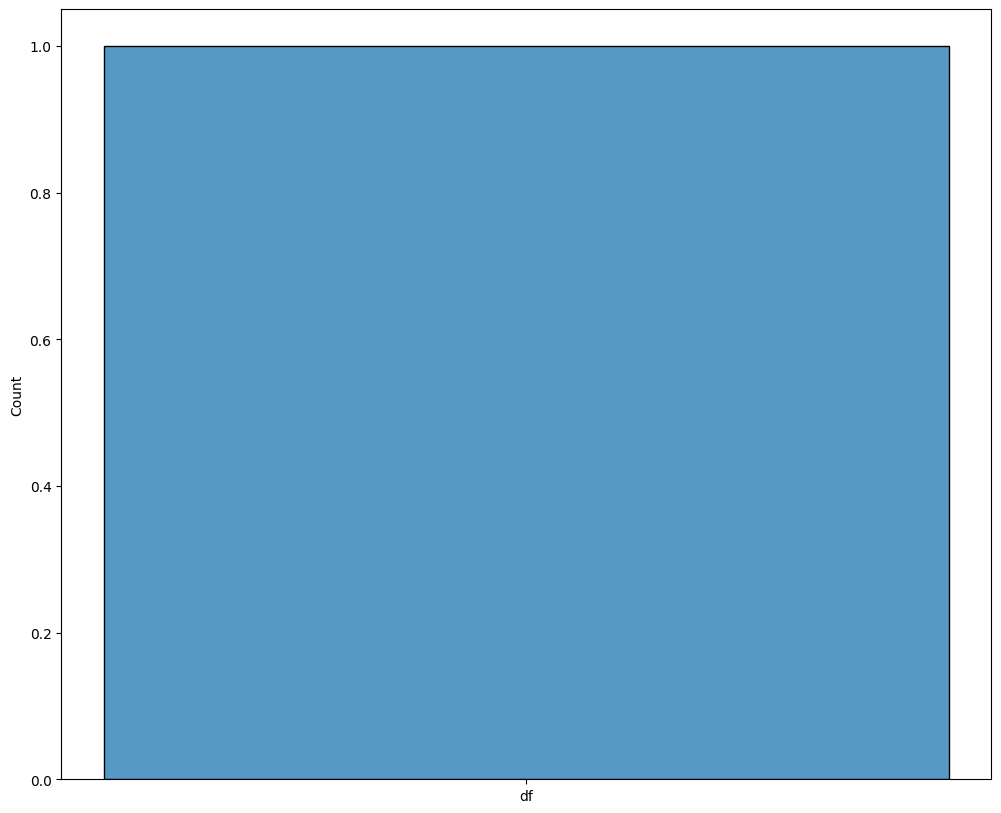

In [124]:
plt.figure(figsize=(12,10))
sns.histplot('df')
plt.show()

<AxesSubplot: ylabel='count'>

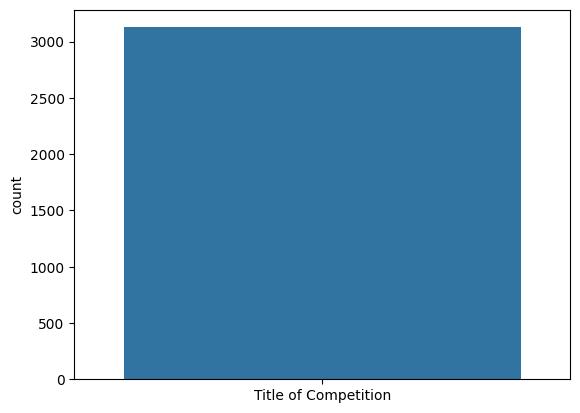

In [125]:
sns.countplot(df)

<AxesSubplot: >

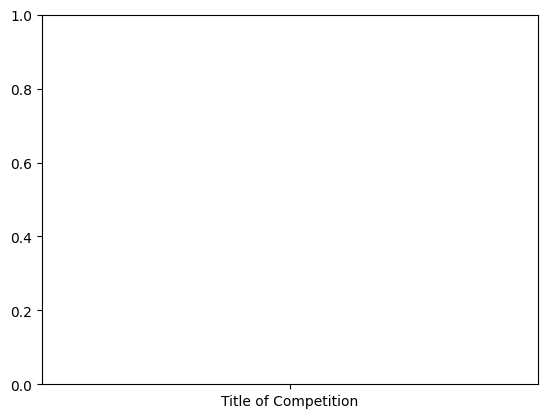

In [126]:
sns.boxplot(df)

<AxesSubplot: ylabel='Density'>

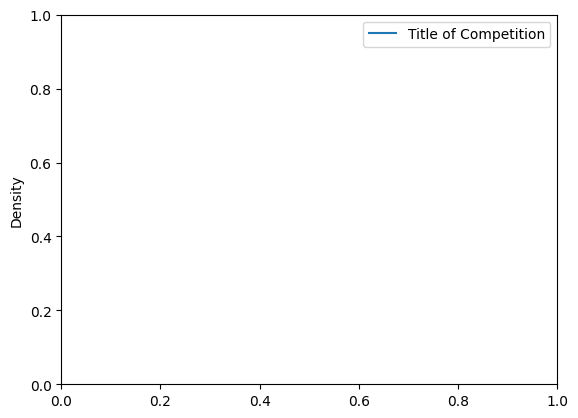

In [127]:
sns.kdeplot(df)

<AxesSubplot: >

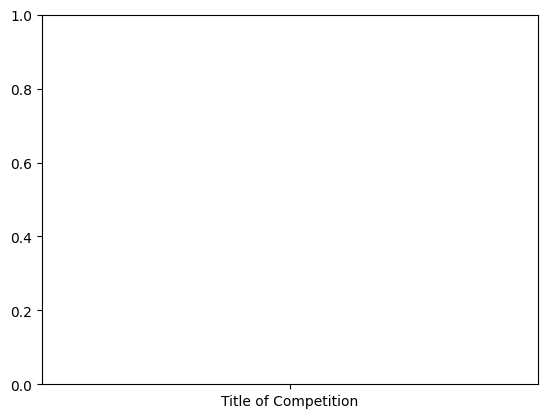

In [128]:
sns.violinplot(df)

<AxesSubplot: >

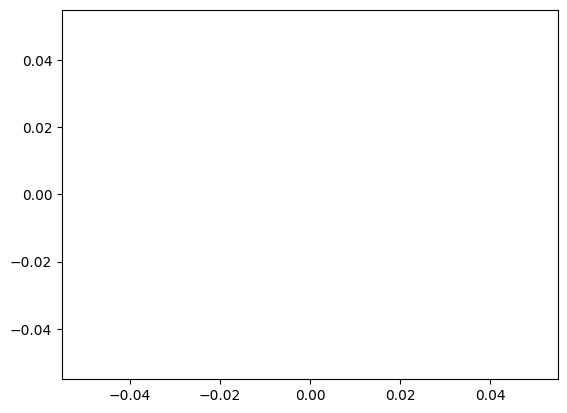

In [129]:
sns.scatterplot(df)

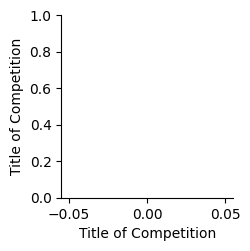

In [130]:
sns.pairplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


<AxesSubplot: >

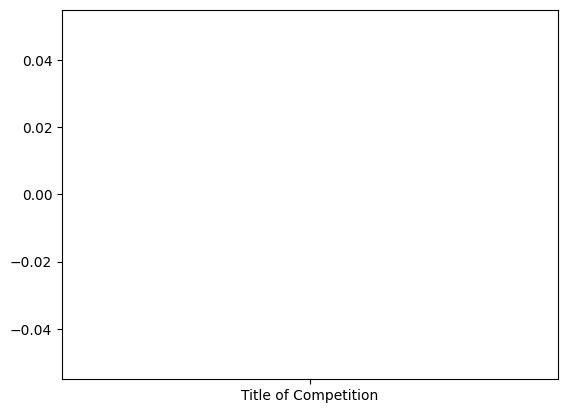

In [131]:
sns.barplot(df)

In [132]:
df.bool

<bound method NDFrame.bool of      Competition Launch Date  Title of Competition  \
0        08/03/2010 00:00:00                   NaN   
1        08/03/2010 00:00:00                   NaN   
2        08/03/2010 00:00:00                   NaN   
3        08/03/2010 00:00:00                   NaN   
4        08/03/2010 00:00:00                   NaN   
...                      ...                   ...   
3122     02/23/2023 17:25:32                   NaN   
3123     02/23/2023 17:25:32                   NaN   
3124     02/23/2023 17:25:32                   NaN   
3125     02/23/2023 17:25:32                   NaN   
3126     02/23/2023 17:25:32                   NaN   

                     Competition URL      Date of Writeup  \
0      https://www.kaggle.com/c/2447  11/18/2010 00:06:46   
1      https://www.kaggle.com/c/2447  11/20/2010 04:38:53   
2      https://www.kaggle.com/c/2447  11/23/2010 10:38:23   
3      https://www.kaggle.com/c/2447  11/20/2010 11:27:17   
4      https://w